In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
foods = pd.read_csv('../data/processed/foods_cleaned.csv')
fao_meat = pd.read_csv('../data/raw/FAOSTAT_meat_prod_2024.csv')


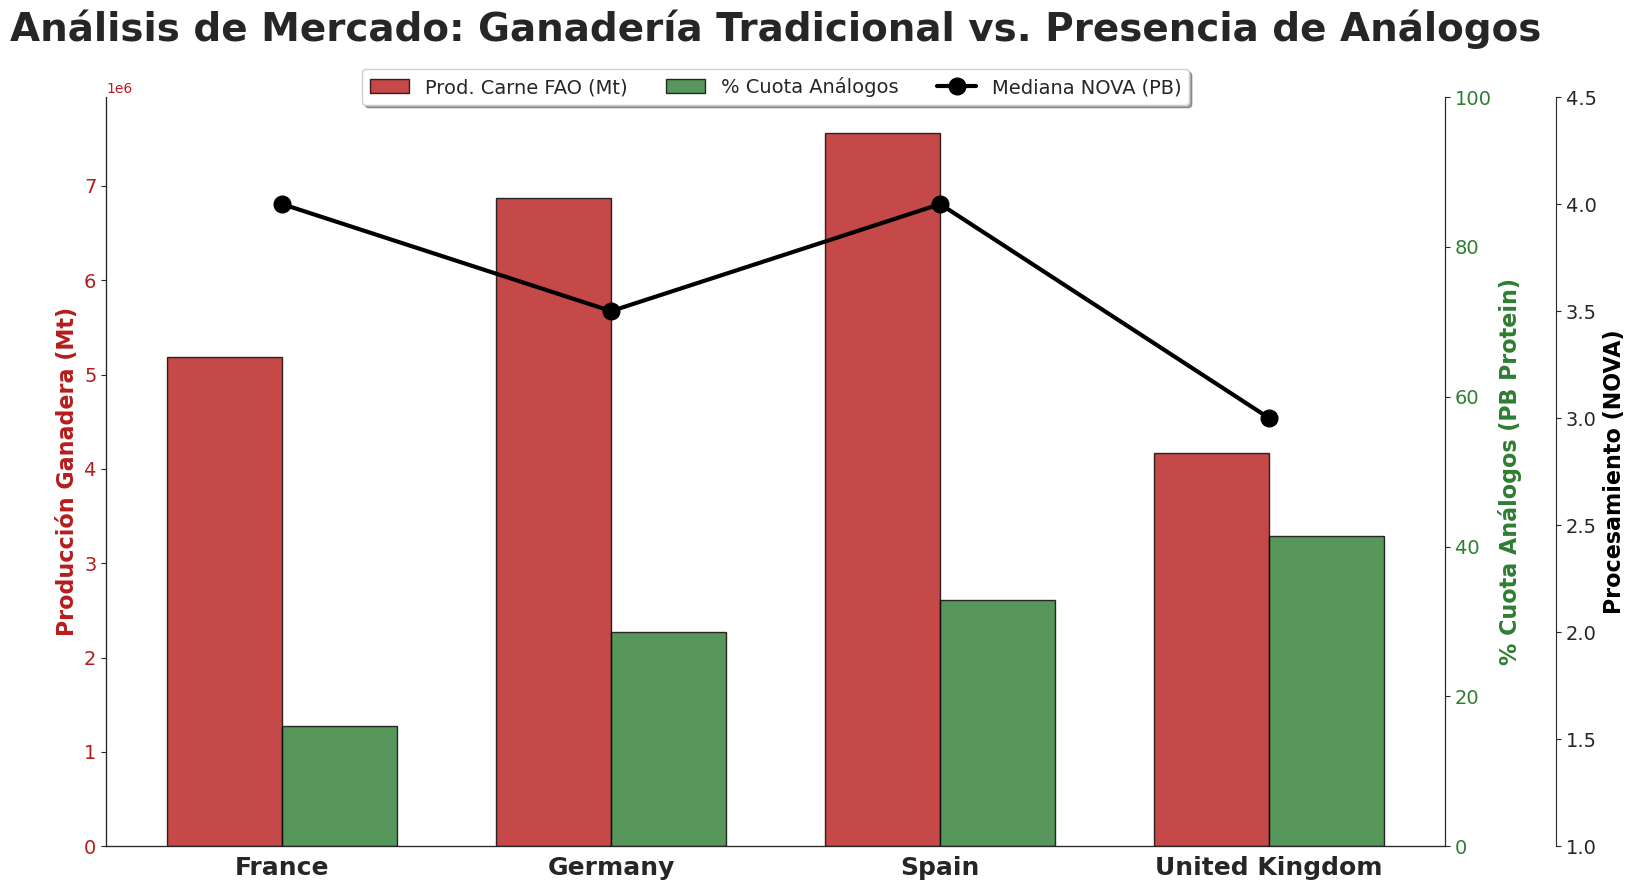

In [32]:
# --- ANÁLISIS ESTRATÉGICO: MERCADO CÁRNICO VS. PRESENCIA VEGETAL ---

# 1. Configuración de Países y Categorías
paises_interes = ['France', 'Spain', 'United Kingdom', 'Germany']
cat_interes = ['meat_fish', 'plant_based_protein']

# 2. Procesamiento de OpenFoodFacts
mask = (foods['main_country'].isin(paises_interes)) & (foods['category_unified'].isin(cat_interes))
subset = foods[mask].copy()

# Agregación y cálculo de cuota de mercado relativa
stats = subset.groupby(['main_country', 'category_unified']).agg(
    conteo=('code', 'count'),
    nova_mediana=('nova_group', 'median')
).unstack(fill_value=0)

# Aplanamos MultiIndex y calculamos el % de penetración de análogos
stats.columns = [f"{c[1]}_{c[0]}" for c in stats.columns]
stats['total_proteina'] = stats['meat_fish_conteo'] + stats['plant_based_protein_conteo']
stats['pct_analogos'] = (stats['plant_based_protein_conteo'] / stats['total_proteina']) * 100

# 3. Integración con FAO (Asegurando nombres de países)
fao_clean = fao_meat[fao_meat['Item'] == 'Meat, Total'][['Area', 'Value']].copy()
df_mkt = pd.merge(stats.reset_index(), fao_clean, left_on='main_country', right_on='Area')

# 4. Visualización de Triple Eje (Estilo Económico)
fig, ax1 = plt.subplots(figsize=(16, 9))
sns.set_style("white")

x = np.arange(len(df_mkt))
width = 0.35

# EJE 1: Producción FAO (Toneladas de Carne) - BARRAS ROJAS
color_fao = '#B71C1C' # Rojo oscuro (Carne)
rects1 = ax1.bar(x - width/2, df_mkt['Value'], width, label='Prod. Carne FAO (Mt)', color=color_fao, alpha=0.8, edgecolor='black')
ax1.set_ylabel('Producción Ganadera (Mt)', fontsize=16, fontweight='bold', color=color_fao)
ax1.tick_params(axis='y', labelcolor=color_fao, labelsize=14)

# EJE 2: Cuota de Análogos (PB Protein) - BARRAS VERDES
ax2 = ax1.twinx()
color_pb = '#2E7D32' # Verde bosque (Vegetal)
rects2 = ax2.bar(x + width/2, df_mkt['pct_analogos'], width, label='% Cuota Análogos', color=color_pb, alpha=0.8, edgecolor='black')
ax2.set_ylabel('% Cuota Análogos (PB Protein)', fontsize=16, fontweight='bold', color=color_pb)
ax2.tick_params(axis='y', labelcolor=color_pb, labelsize=14)
ax2.set_ylim(0, 100)

# EJE 3: Grado de Procesamiento (NOVA) - LÍNEA NEGRA
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 80)) # Desplazamiento del tercer eje
line3 = ax3.plot(df_mkt['main_country'], df_mkt['plant_based_protein_nova_mediana'], 
                 color='black', marker='o', markersize=12, linewidth=3, label='Mediana NOVA (PB)')
ax3.set_ylabel('Procesamiento (NOVA)', fontsize=16, fontweight='bold', color='black')
ax3.set_ylim(1, 4.5)
ax3.tick_params(axis='y', labelsize=14)

# Estética y Títulos
plt.title('Análisis de Mercado: Ganadería Tradicional vs. Presencia de Análogos', 
          fontsize=28, fontweight='bold', pad=40)

ax1.set_xticks(x)
ax1.set_xticklabels(df_mkt['main_country'], fontsize=18, fontweight='bold')

# Leyenda unificada superior
all_h, all_l = [], []
for ax in [ax1, ax2, ax3]:
    h, l = ax.get_legend_handles_labels()
    all_h.extend(h)
    all_l.extend(l)
ax1.legend(all_h, all_l, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3, fontsize=14, frameon=True, shadow=True)

sns.despine(right=False)
plt.tight_layout()
plt.savefig('../images/04_h04/4.1_Carne_Analogos_Procesado.png', bbox_inches='tight', dpi=300)
plt.show()

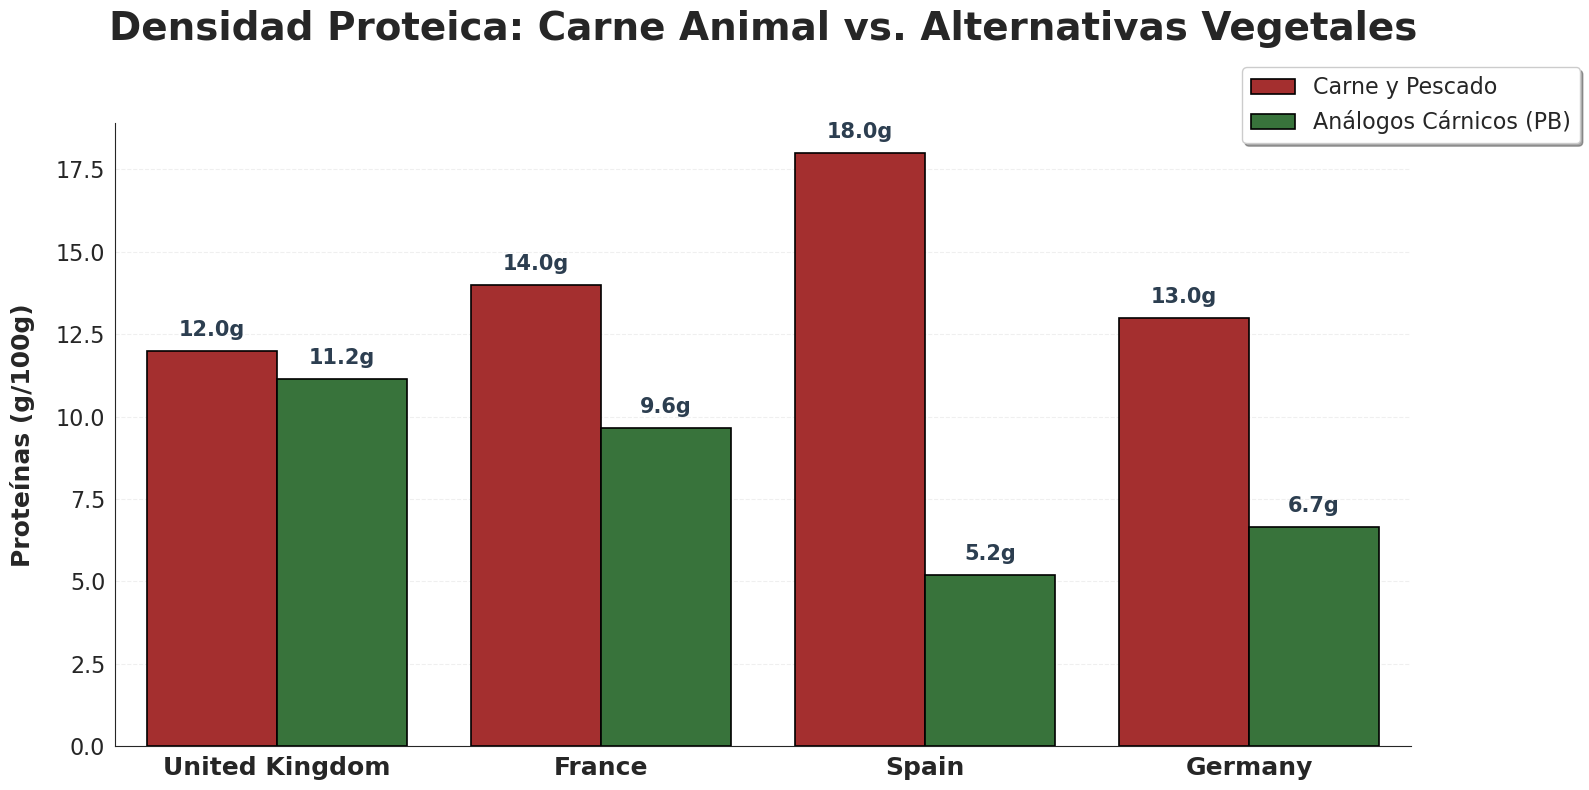

In [34]:
# --- COMPARATIVA DE DENSIDAD PROTEICA---

# 1. Configuración y Traducción
paises = ['France', 'Spain', 'United Kingdom', 'Germany']
traduccion_prot = {
    'meat_fish': 'Carne y Pescado',
    'plant_based_protein': 'Análogos Cárnicos (PB)'
}

# 2. Filtrado y Mapeo
df_protein = foods[
    (foods['main_country'].isin(paises)) & 
    (foods['category_unified'].isin(traduccion_prot.keys()))
].copy()

df_protein['categoria_es'] = df_protein['category_unified'].map(traduccion_prot)

# 3. Visualización de Alto Impacto
plt.figure(figsize=(16, 8))
sns.set_style("white")

# Paleta Semántica: Rojo (Carne) vs Verde (Vegetal)
paleta_prot = {'Carne y Pescado': '#B71C1C', 'Análogos Cárnicos (PB)': '#2E7D32'}

ax = sns.barplot(
    data=df_protein, 
    x='main_country', 
    y='proteins_100g', 
    hue='categoria_es', 
    palette=paleta_prot,
    estimator='median',
    edgecolor='black',
    linewidth=1.2,
    errorbar=None 
) 

# 4. Estética y Fuentes Maximizadas
plt.title("Densidad Proteica: Carne Animal vs. Alternativas Vegetales", 
          fontsize=28, fontweight='bold', pad=60)

plt.ylabel("Proteínas (g/100g)", fontsize=18, fontweight='bold', labelpad=15)
plt.xlabel("", fontsize=1) 

plt.xticks(fontsize=18, fontweight='bold')
plt.yticks(fontsize=16)

# Leyenda superior centrada (ajustada para no solapar)
plt.legend(
    title="", 
    fontsize=16, 
    loc='lower center', 
    bbox_to_anchor=(1, 0.95), 
    ncol=1, 
    frameon=True, 
    shadow=True
)

# 5. Anotaciones de la media (Ajustadas al eliminar el errorbar)
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0:
        ax.annotate(f'{height:.1f}g', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 8), # Reducimos el espacio al no haber bigotes de error
                    textcoords='offset points',
                    fontsize=15, fontweight='bold', color='#2c3e50')

sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('../images/04_h04/4.2_Carne_Analogos_Proteina.png', bbox_inches='tight', dpi=300)
plt.show()